## 어텐션

### 어텐션의 구조
* seq2seq는 다양하게 응용할 수 있음
* 어텐션 메커니즘으로 seq2seq는 필요한 정보에만 주목할 수 있음
* 또한 지금까지의 seq2seq의 문제도 해결 가능

#### seq2seq의 문제점
* seq2seq에서는 Encoder가 시계열 데이터를 인코딩 후 Decoder로 전달
* Encoder의 출력은 고정 길이의 벡터  
-> 고정 길이가 문제
* 즉, 아무리 긴 문장이 입력되어도 항상 같은 길이의 벡터에 넣어야 함  
-> 필요한 정보가 벡터에 다 담기지 못하게 됨

#### Encoder 개선
* Encoder 출력의 길이는 입력 문장의 길이에 따라 바꾸주는 것이 좋음
* LSTM 계층의 은닉 상태 벡터를 모두 이용
* 시각별 LSTM 계층의 은닉 상태에는 직전에 입력된 단어에 대한 정보가 많이 포함됨  
    -> Encoder가 출력하는 hs 행렬은 각 단어에 해당하는 벡터들의 집합

#### Decoder 개선 1
* Decoder는 각 단어에 대응하는 LSTM 계층의 은닉 상태 벡터를 hs로 모아 출력
* hs가 Decoder에 전달되어 시계열 변환이 이루어짐
* 단순한 seq2seq는 Encoder의 LSTM 계층의 마짐가 은닉 상태를 Deocder의 LSTM 계층의 첫 은닉 상태로 설정

-> 입력과 출력의 여러 단어 중 어떤 단어끼리 서로 연관되어있는가를 seq2seq에 게 학습시킬 수 없을까?

* 목표는 도착어 단어와 대응 관계에 있는 출발어 단어의 정보를 골라내고 그 정보를 이용해 번역을 수행하는 것
* 즉, 필요한 정보에만 주목해 그 정보로부터 시계열 변환을 수행하는 것

* 계산을 하는 계층을 추가
    * 해당 계층은 Encoder로부터 hs, 시각별 LSTM 계층의 은닉 상태를 입력으로 받음
    * 필요한 정보만 골라 Affine 계층으로 출력
* Encoder의 마지막 은닉 상태 벡터는 Decoder의 첫 번째 LSTM 계층에 전달

* 신경망으로 하고 싶은 일은 단어의 얼라인먼트 추출
    * 각 시각에서 Decoder에 입력된 단어와 대응 관계인 단어의 벡터를 hs에서 골라내겠다는 것
* 하지만 선택 작업은 미분할 수 없음  
    -> 미분 가능한 연산으로 대체할 수 없을까?

* 해결 방법은 하나를 선택하지 않고 모든 것을 선택하는 것
* 각 단어의 중요도를 나타내는 가중치를 별도로 계산
    * a: 가중치
    * a는 확률분포처럼 각 원소가 0.0~1.0 사이의 스칼라, 모든 원소의 총합은 1
* a, hs로부터 가중합을 구하여 원하는 벡터를 얻음  
    -> 맥락 벡터 c

In [4]:
import numpy as np

# 가중합을 구하는 구현
T, H = 5, 4
hs = np.random.randn(T, H)
print(hs)
a = np.array([0.8, 0.1, 0.03, 0.05, 0.02])

ar = a.reshape(5, 1).repeat(4, axis=1)
print(ar.shape)

t = hs * ar
print(t.shape)

c = np.sum(t, axis=0)
print(c.shape)
print(c)

[[ 0.75787378 -0.55608511 -0.79343757  0.949753  ]
 [-2.34331068 -1.05551295  0.1459489  -0.16293029]
 [-0.39081379  0.45837402  1.29700455 -1.01079011]
 [ 0.00491856  0.96297061 -0.39095108  1.03892435]
 [ 1.16200357  0.20675999 -0.13777362  1.27643459]]
(5, 4)
(5, 4)
(4,)
[ 0.38372954 -0.48438443 -0.60354806  0.79066058]


* 가중합을 구함
    * 시계열의 길이를 T=5
    * 은닉 상태 벡터의 원소 수를 H=4

In [6]:
# 미니배치 처리용 가중합
N, T, H = 10, 5, 4
hs = np.random.randn(N, T, H)
a = np.random.randn(N, T)
ar = a.reshape(N, T, 1).repeat(H, axis=2)

t = hs * ar
print(t.shape)

c = np.sum(t, axis=1)
print(c.shape)

(10, 5, 4)
(10, 4)


In [7]:
# 계산 그래프의 역전파
class WeightSum:
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None
    
    def forward(self, hs, a):
        N, T, H = hs.shape

        ar = a.reshape(N, T, 1).repeat(H, axis=2)
        t = hs * ar
    
        c = np.sum(t, axis=1)

        self.cache = (hs, ar)
        return c

    def backward(self, dc):
        hs, ar = self.cache
        N, T, H = hs.shape

        dt = dc.reshape(N, 1, H).repeat(T, axis=1) # sum 역전파
        dar = dt * hs
        dhs = dt * ar
        da = np.sum(dar, axis=2) # repeat 역전파

        return dhs, da

#### Decoder 개선 2
* 각 단어의 중요도를 나타내는 가중치 a가 있다면 가중합으로 맥락 벡터를 얻을 수 있음  
    -> a는 어떻게 구하는가?

* h가 hs의 각 단어 벡터와 얼마나 비슷한가를 수치로 나타냄  
    -> 벡터의 내적을 이용
        * 벡터의 내적은 두 벡터가 얼마나 같은 방향을 향하고 있는가
* s는 h와 hs의 유사도이며 점수라고도 함
* s를 정규화하기 위해 소프트맥스 적용
* 소프트맥스를 이용하면 출력인 a의 각 원소는 0.0~1.0 사이의 값이 되고 모든 원소의 총합은 1이 됨

In [8]:
# a를 구하는 과정
from common.layers import Softmax
import numpy as np

N, T, H = 10, 5, 4
hs = np.random.randn(N, T, H)
h = np.random.randn(N, H)
hr = h.reshape(N, 1, H).repeat(T, axis=1)
# hr = h.reshape(N, 1, H) # 브로드캐스트 사용 시

t = hs * hr
print(t.shape)

s = np.sum(t, axis=2)
print(s.shape)

softmax = Softmax()
a = softmax.forward(s)
print(a.shape)

(10, 5, 4)
(10, 5)
(10, 5)


* 계산 그래프가 표현하는 처리는 AttentionWeight 클래스로 구현

In [9]:
class AttentionWeight:
    def __init__(self):
        self.params, self.grads = [], []
        self.softmax = Softmax()
        self.cache = None

    def forward(self, hs, h):
        N, T, H = hs.shape

        hr = h.reshape(N, 1, H)#.repeat(T, axis=1)
        t = hs * hr
        s = np.sum(t, axis=2)
        a = self.softmax.forward(s)

        self.cache = (hs, hr)
        return a

    def backward(self, da):
        hs, hr = self.cache
        N, T, H = hs.shape

        ds = self.softmax.backward(da)
        dt = ds.reshape(N, T, 1).repeat(H, axis=2)
        dhs = dt * hr
        dhr = dt * hs
        dh = np.sum(dhr, axis=1)

        return dhs, dh

#### Decoder 개선 3
* Attention Weight 계층, Weight Sum 계층을 결합!

* Attention 계층
    * hs에서부터 c를 출력하는 일련의 계산을 수행하는 계층
* Encoder가 건네주는 정보 hs에서 중요한 원소에 주목하여 그것을 바탕으로 맥락 벡터를 구해 위쪽 계층으로 전파

In [11]:
class Attention:
    def __init__(self):
        self.params, self.grads = [], []
        self.attention_weight_layer = AttentionWeight()
        self.weight_sum_layer = WeightSum()
        self.attention_weight = None

    def forward(self, hs, h):
        a = self.attention_weight_layer.forward(hs, h)
        out = self.weight_sum_layer.forward(hs, a)
        self.attention_weight = a
        return out

    def backward(self, dout):
        dhs0, da = self.weight_sum_layer.backward(dout)
        dhs1, dh = self.attention_weight_layer.backward(da)
        dhs = dhs0 + dhs1
        return dhs, dh

* 시계열 방향으로 다수의 Attention 계층을 Time Attention 계층으로 모아 구현

In [12]:
class TimeAttention:
    def __init__(self):
        self.params, self.grads = [], []
        self.layers = None
        self.attention_weights = None

    def forward(self, hs_enc, hs_dec):
        N, T, H = hs_dec.shape
        out = np.empty_like(hs_dec)
        self.layers = []
        self.attention_weights = []

        for t in range(T):
            layer = Attention()
            out[:, t, :] = layer.forward(hs_enc, hs_dec[:,t,:])
            self.layers.append(layer)
            self.attention_weights.append(layer.attention_weight)

        return out

    def backward(self, dout):
        N, T, H = dout.shape
        dhs_enc = 0
        dhs_dec = np.empty_like(dout)

        for t in range(T):
            layer = self.layers[t]
            dhs, dh = layer.backward(dout[:, t, :])
            dhs_enc += dhs
            dhs_dec[:,t,:] = dh

        return dhs_enc, dhs_dec

* Attention 계층을 필요한 수만큼 만들고 각각 순전파와 역전파를 수행
* Attention 계층의 각 단어의 가중치를 attention_weights 리스트에서 보관

### 어텐션을 갖춘 seq2seq 구현

#### Encoder 구현
* 앞 장의 Encoder 클래스의 forward() 메서드와는 달리 모든 은닉 상태를 반환

In [14]:
import sys
sys.path.append('..')
from common.time_layers import *
from seq2seq import Encoder, Seq2seq
from attention_layer import TimeAttention


class AttentionEncoder(Encoder):
    def forward(self, xs):
        xs = self.embed.forward(xs)
        hs = self.lstm.forward(xs)
        return hs

    def backward(self, dhs):
        dout = self.lstm.backward(dhs)
        dout = self.embed.backward(dout)
        return dout

#### Decoder 구현
* Softmax 계층 앞까지를 Decoder로 구현
* forward(), backward()에 generate() 메서드도 추가

In [15]:
class AttentionDecoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(2*H, V) / np.sqrt(2*H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True)
        self.attention = TimeAttention()
        self.affine = TimeAffine(affine_W, affine_b)
        layers = [self.embed, self.lstm, self.attention, self.affine]

        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, enc_hs):
        h = enc_hs[:,-1]
        self.lstm.set_state(h)

        out = self.embed.forward(xs)
        dec_hs = self.lstm.forward(out)
        c = self.attention.forward(enc_hs, dec_hs)
        out = np.concatenate((c, dec_hs), axis=2)
        score = self.affine.forward(out)

        return score

    def backward(self, dscore):
        dout = self.affine.backward(dscore)
        N, T, H2 = dout.shape
        H = H2 // 2

        dc, ddec_hs0 = dout[:,:,:H], dout[:,:,H:]
        denc_hs, ddec_hs1 = self.attention.backward(dc)
        ddec_hs = ddec_hs0 + ddec_hs1
        dout = self.lstm.backward(ddec_hs)
        dh = self.lstm.dh
        denc_hs[:, -1] += dh
        self.embed.backward(dout)

        return denc_hs

    def generate(self, enc_hs, start_id, sample_size):
        sampled = []
        sample_id = start_id
        h = enc_hs[:, -1]
        self.lstm.set_state(h)

        for _ in range(sample_size):
            x = np.array([sample_id]).reshape((1, 1))

            out = self.embed.forward(x)
            dec_hs = self.lstm.forward(out)
            c = self.attention.forward(enc_hs, dec_hs)
            out = np.concatenate((c, dec_hs), axis=2)
            score = self.affine.forward(out)

            sample_id = np.argmax(score.flatten())
            sampled.append(sample_id)

        return sampled

#### seq2seq 구현
* AttentionEncoder, AttentionDecoder를 사용하고 Seq2seq 클래스를 상속하고 초기화 메서드를 수정하는 것으로 구현

In [17]:
class AttentionSeq2seq(Seq2seq):
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        args = vocab_size, wordvec_size, hidden_size
        self.encoder = AttentionEncoder(*args)
        self.decoder = AttentionDecoder(*args)
        self.softmax = TimeSoftmaxWithLoss()

        self.params = self.encoder.params + self.decoder.params
        self.grads = self.encoder.grads + self.decoder.grads

### 어텐션 평가

#### 날짜 형식 변환 문제
* 영어권에서 사용되는 다양한 날짜 형식을 표준 형식으로 변환하는 것이 목표
* 겉보기처럼 간단하지 않음
* 문제의 입력과 출력 사이에 알기 쉬운 대응 관계가 있음  
    -> 어텐션이 각각의 원소에 올바르게 주목하고 있는지를 확인할 수 있음

#### 어텐션을 갖춘 seq2seq의 학습

In [ ]:
# coding: utf-8
import sys
sys.path.append('..')
sys.path.append('../ch07')
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq
from seq2seq import Seq2seq
from peeky_seq2seq import PeekySeq2seq


# 데이터 읽기
(x_train, t_train), (x_test, t_test) = sequence.load_data('date.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 입력 문장 반전
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 256
batch_size = 128
max_epoch = 10
max_grad = 5.0

model = AttentionSeq2seq(vocab_size, wordvec_size, hidden_size)
# model = Seq2seq(vocab_size, wordvec_size, hidden_size)
# model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)

optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse=True)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('정확도 %.3f%%' % (acc * 100))


model.save_params()

# 그래프 그리기
x = np.arange(len(acc_list))
plt.plot(x, acc_list, marker='o')
plt.xlabel('에폭')
plt.ylabel('정확도')
plt.ylim(-0.05, 1.05)
plt.show()

#### 어텐션 시각화

c:\Users\기현\Desktop\cs\deep_learning\deep_learning_from_scratch_2\common\base_model.py:42: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  params = pickle.load(f)


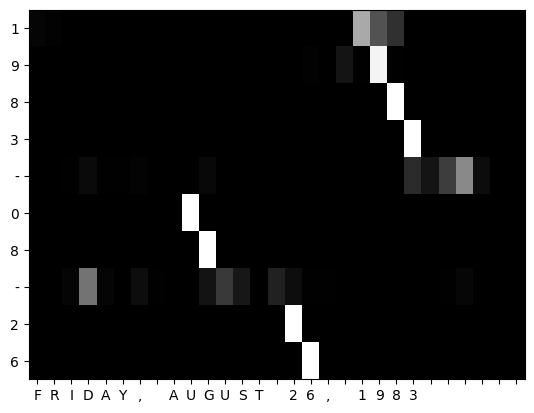

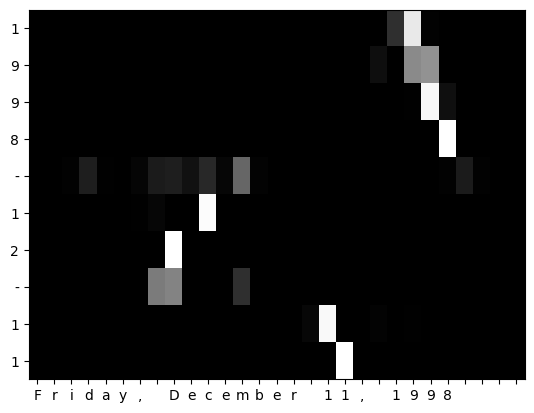

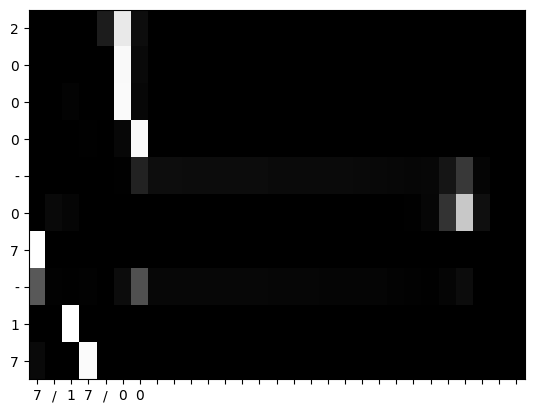

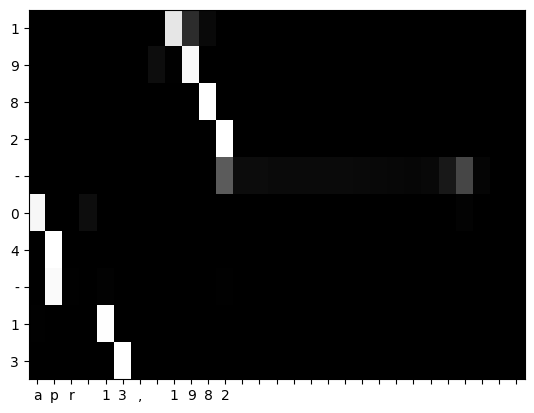

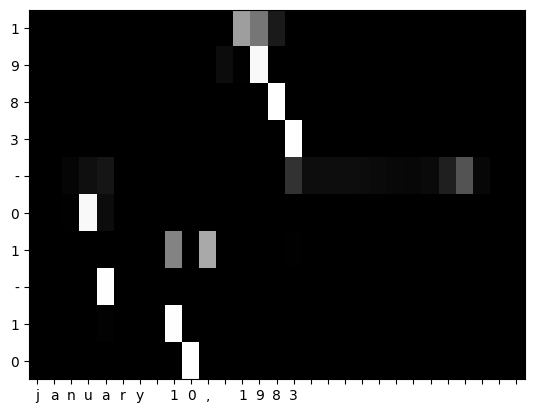

In [19]:
# coding: utf-8
import sys
sys.path.append('..')
import numpy as np
from dataset import sequence
import matplotlib.pyplot as plt


(x_train, t_train), (x_test, t_test) = \
    sequence.load_data('date.txt')
char_to_id, id_to_char = sequence.get_vocab()

# 입력 문장 반전
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]

vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 256

model = AttentionSeq2seq(vocab_size, wordvec_size, hidden_size)
model.load_params()

_idx = 0
def visualize(attention_map, row_labels, column_labels):
    fig, ax = plt.subplots()
    ax.pcolor(attention_map, cmap=plt.cm.Greys_r, vmin=0.0, vmax=1.0)

    ax.patch.set_facecolor('black')
    ax.set_yticks(np.arange(attention_map.shape[0])+0.5, minor=False)
    ax.set_xticks(np.arange(attention_map.shape[1])+0.5, minor=False)
    ax.invert_yaxis()
    ax.set_xticklabels(row_labels, minor=False)
    ax.set_yticklabels(column_labels, minor=False)

    global _idx
    _idx += 1
    plt.show()


np.random.seed(1984)
for _ in range(5):
    idx = [np.random.randint(0, len(x_test))]
    x = x_test[idx]
    t = t_test[idx]

    model.forward(x, t)
    d = model.decoder.attention.attention_weights
    d = np.array(d)
    attention_map = d.reshape(d.shape[0], d.shape[2])

    # 출력하기 위해 반전
    attention_map = attention_map[:,::-1]
    x = x[:,::-1]

    row_labels = [id_to_char[i] for i in x[0]]
    column_labels = [id_to_char[i] for i in t[0]]
    column_labels = column_labels[1:]

    visualize(attention_map, row_labels, column_labels)


* seq2seq는 대응하는 사실을 데이터만 가지고 학습해냄

### 어텐션에 관한 남은 이야기

#### 양방향 RNN
* LSTM의 각 시각의 은닉 상태 벡터는 hs로 모아짐
* Encoder가 출력하는 hs의 각 행에는 그 행에 대응하는 단어의 성분이 많이 포함되어 있음

* 주목할 것은 글을 왼쪽에서 오른쪽으로 읽는다는 점
* 전체적인 균형을 생각하면 단어의 주변 정보를 균형 있게 담고 싶을 것

-> LSTM을 양방향으로 처리하는 방법을 생각할 수 있음

=> 양방향 LSTM!

* 양방향 LSTM에서는 기존의 LSTM에 더해 역방향으로 처리하는 LSTM 계층도 추가
* 각 시각에서는 두 LSTM 계층의 은닉 상태를 연결시킨 벡터를 최종 은닉 상태로 처리
* 양방향으로 처리함으로써 각 단어에 대응하는 은닉 상태 벡터에는 양방향으로부터 정보를 집약할 수 있음  
-> 균형 잡힌 정보가 인코딩!

* 구현
    * 2개의 LSTM 계층을 사용해 각각의 계층에 주는 단어의 순서를 조정
        * 기존 LSTM 계층 + 입력 문장의 단어들을 반대 순서로 나열하는 LSTM 계층

#### Attention 계층 사용 방법
* Attention 계층의 위치를 달리하는 게 최종 정확도에는 어떤 영향이 줄까?  
-> 안 해보면 모름

#### seq2seq 심층화와 skip 연결
* 어텐션을 갖춘 seq2seq에도 더 높은 표현력이 요구될 것

* Encoder와 Decoder에서는 같은 LSTM 계층을 이용하는 것이 일반적
* Attention 계층의 사용법은 여러 변형이 있을 수 있음
    * 여기서는 Decoder의 LSTM 계층의 은닉 상태를 Attention 계층에 입력하고 Attention 계층의 출력인 맥락 벡터를 Decoder의 여러 계층으로 전파

* 층을 깊게 할 때 사용되는 중요한 기법 중 skip 연결이 있음
    * 잔차 연결 또는 숏컷이라고도 함
* 계층을 넘어 선을 연결하는 단순한 기법

* skip 연결은 계층을 건너뛰는 연결
* skip 연결의 접속부에서는 2개의 출력이 더해짐
* 덧셈이 핵심
    * 덧셈은 역전파 시 기울기를 그대로 흘려보내므로 skip 연결의 기울기가 아무런 영향을 받지 않고 모든 계층으로 흐름  
        -> 기울기 소실 또는 폭발이 없음

### 어텐션 응용

#### 구글 신경망 기계 번역(GNMT)
* 기계 번역의 역사
    * 규칙 기반 번역 -> 용례 기반 번역 -> 통계 기반 번역  

-> 현재는 신경망 기계 번역(NMT)

* GNMT도 Encoder, Decoder, Attention으로 구성
    * LSTM 계층의 다층화
    * 양방향 LSTM (Encoder의 첫 계층만)
    * skip 연결
    * GPU로 분산 학습
* GNMT는 번역 품질을 크게 끌어올림
* 다만 아직도 자연스럽지 못하거나 사람이 안 하는 실수도 함

#### 트랜스포머
* RNN의 계산을 시간 방향으로 병렬 계산하는 것은 기본적으로 불가능
    * GPU를 사용한 병렬 계산 환경에서 이뤄진다는 점을 생각하면 큰 병목
* 트랜스포머 모델은 RNN이 아닌 어텐션을 사용해 처리

* 트랜스포머는 어텐션으로 구성
    * 셀프어텐션을 이용하는 것이 핵심
* 셀프어텐션은 하나의 시계열 데이터를 대상으로 한 어텐션
    * 하나의 시계열 데이터 내에서 각 원소가 다른 원소들과 어떻게 관련되는 지를 살펴보기 위함

* Time Attention 계층에는 서로 다른 두 시계열 데이터가 입력
* Self-Attention은 두 입력선이 모두 하나의 시계열 데이터로부터 나옴  
-> 하나의 시계열 데이터 내에서의 원소 간 대응 관계가 구해짐

* 트랜스포머에서는 RNN 대신 어텐션 사용
    * Encoder, Decoder 모두 셀프어텐션을 사용
    * Feed Forward 계층은 피드포워드 신경망으로 은닉층이 1개이고 활성화 함수로 ReLU를 이용한 완전연결계층 신경망을 이용

* 트랜스포머는 계산량을 줄이고 GPU를 이용한 병렬 계산의 혜택을 더 많이 볼 수 있음

#### 뉴럴 튜링 머신(NTM)
* 신경망도 외부 메모리를 이용해 확장할 수 있음
* 어텐션을 통해 Encoder와 Decoder는 메모리 조작같은 작업을 수행
    * Encoder가 필요한 정보를 메모리에 쓰고, Decoder는 그 메모리로부터 필요한 정보를 읽어들이는 것으로 해석할 수 있음
* 메모리 조작을 신경망에서도 재현할 수 있을 것으로 보임
    * RNN의 외부에 정보 저장용 메모리 기능을 배치하고, 어텐션을 이용해 메모리로부터 필요한 정보를 읽거나 쓰는 방법

-> 뉴럴 튜링 머신(NTM)

* 컨트롤러 모듈이 존재
    * 정보를 처리하는 모듈로 신경망을 이용하는 것으로 예상
* 컨트롤러 바깥의 메모리의 존재로 컨트롤러는 컴퓨터같은 능력을 얻음
* 그리고 노드가 필요한 위치의 데이터를 읽고 쓸 수 있음

-> NTM은 외부 메모리를 읽고 쓰면서 시계열 데이터를 처리

* 메모리 조작을 미분 가능한 계산으로 구축

* LSTM 계층이 컨트롤러가 되어 NTM의 주된 처리를 수행
* 각 시각에서 LSTM 계층의 은닉 상태를 Write Head 계층이 받아 필요한 정보를 메모리에 씀
* Read Head 계층이 메모리로부터 중요한 정보를 읽어 들여 다음 시각의 LSTM 계층으로 전달

-> Write Head, Read Head 계층은 어떻게 메모리를 조작히는가?  
=> 어텐션 사용!

* NTM은 2개의 어텐션을 이용
    * 콘텐츠 기반 어텐션
        * 입력으로 주어진 질의 벡터와 비슷한 벡터를 메모리로부터 찾아내는 용도로 사용
    * 위치 기반 어텐션
        * 이전 시각에서 주목한 메모리의 위치(=메모리의 각 위치에 대한 가중치)를 기준으로 그 전후로 이동(시프트)하는 용도로 사용

* 외부 메모리를 자유롭게 이용하게 됨으로써 seq2seq만으로는 풀리지 않는 복잡한 문제도 높은 성과를 드러냄
    * 긴 시계열을 기억하는 문제와 정렬 등
* NTM은 외부 메모리를 사용함으로써 알고리즘을 학습하는 능력을 얻음
    * 어텐션이 중요한 기술로써 이용